In [1]:
# Imports + data simulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

np.random.seed(42)

n = 1000

data = pd.DataFrame({
    "user_id": range(n),
    "group": np.random.choice(["control", "treatment"], n),
    "prior_engagement": np.random.normal(50, 10, n)
})

data["watch_time"] = data["prior_engagement"] + \
    np.where(data["group"] == "treatment",
             np.random.normal(10, 5, n),
             np.random.normal(0, 5, n))

data.head()

,user_id,group,prior_engagement,watch_time
0,0,control,53.417560,52.265556
1,1,treatment,68.761708,86.569264
2,2,control,59.504238,63.955230
3,3,control,44.230963,49.407210
4,4,control,41.015853,31.784914


# 🎬 Evaluating the Impact of Recommendation Systems on User Engagement

## 🧠 Business Problem

Streaming platforms rely heavily on recommendation systems to drive user engagement and retention.

This analysis evaluates whether a new recommendation algorithm increases user watch time compared to the existing system.

Understanding this impact is critical for:
- Improving content discovery  
- Increasing engagement  
- Supporting data-driven product decisions  

## ⚙️ Approach

To measure impact, we simulate an A/B test:

- Control group: Existing recommendation system  
- Treatment group: New recommendation algorithm  

We evaluate:
- Watch time differences  
- Statistical significance (t-test)  
- Causal impact using regression analysis controlling for prior engagement  

## 📊 Data

The dataset includes:
- user_id  
- group (control vs treatment)  
- prior_engagement  
- watch_time  

Data is simulated to reflect user engagement behavior.

## 📊 Data Exploration

We summarize the dataset to understand overall engagement patterns.

In [2]:
data.describe()

,user_id,prior_engagement,watch_time
count,1000.000000,1000.000000,1000.000000
mean,499.500000,50.401664,55.537216
std,288.819436,10.012925,12.059980
min,0.000000,21.037446,19.850272
25%,249.750000,43.749954,47.420959
50%,499.500000,50.366335,55.711199
75%,749.250000,56.815984,64.170068
max,999.000000,80.788808,90.260080


## 📈 Group Comparison

We compare average watch time between control and treatment groups.

In [3]:
data.groupby("group")["watch_time"].mean()

group
control      50.425738
treatment    60.448245
Name: watch_time, dtype: float64

The treatment group shows approximately 10 units higher average watch time compared to the control group, suggesting a strong initial signal that the recommendation algorithm improves engagement.

## 📊 Visualization

We visualize differences in watch time between groups.

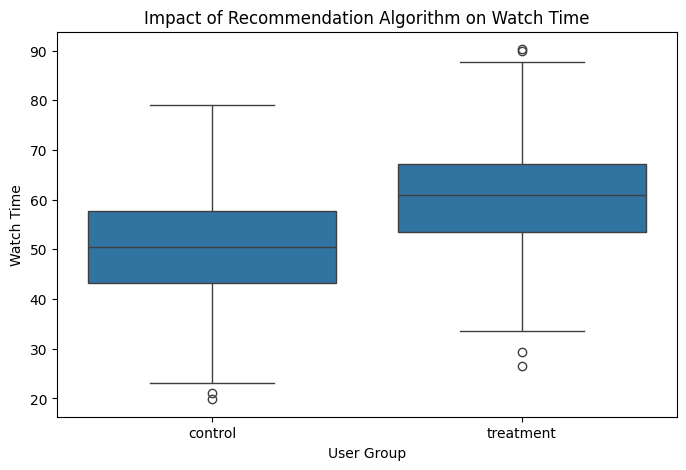

In [4]:
plt.figure(figsize=(8,5))
sns.boxplot(x="group", y="watch_time", data=data)
plt.title("Impact of Recommendation Algorithm on Watch Time")
plt.xlabel("User Group")
plt.ylabel("Watch Time")
plt.show()

## 🧪 A/B Testing

We test whether the difference in watch time is statistically significant.

In [5]:
control = data[data["group"] == "control"]["watch_time"]
treatment = data[data["group"] == "treatment"]["watch_time"]

t_stat, p_value = stats.ttest_ind(treatment, control)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: 14.43715062467623
P-value: 4.7623574007846374e-43


The extremely low p-value indicates that the observed difference is statistically significant and unlikely to be due to random chance.

## 🧠 Causal Inference

We estimate the causal impact of the recommendation algorithm using regression while controlling for prior engagement.

In [6]:
data["treatment_flag"] = (data["group"] == "treatment").astype(int)

X = data[["treatment_flag", "prior_engagement"]]
X = sm.add_constant(X)
y = data["watch_time"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             watch_time   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     2511.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:29:42   Log-Likelihood:                -3009.4
No. Observations:                1000   AIC:                             6025.
Df Residuals:                     997   BIC:                             6040.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.9893      0.814  

After controlling for prior engagement, the treatment effect remains significant, confirming a true causal impact rather than a difference driven by user behavior.

## 📊 Results

- The treatment group shows higher average watch time  
- The difference is statistically significant (p < 0.001)  
- Estimated causal lift of ~10 units (regression coefficient on treatment variable)

The recommendation algorithm has a meaningful positive impact on engagement.

## ⚠️ Limitations

- Data is simulated and may not reflect real-world user behavior  
- External factors influencing engagement are not included  
- Results should be validated using production data  

Despite these limitations, the analysis demonstrates a clear framework for evaluating product changes.

## 🚀 Business Recommendation

Based on the analysis, the recommendation algorithm should be considered for rollout.

Next steps:
- Validate with real-world data  
- Analyze long-term retention  
- Test across user segments  

These findings support data-driven product decisions.